# Notebook 05 — Tables 5 & 6 + Figures 9 & 10: Centroid Characteristics

**Data needed:**
- `data/grid/cluster_month_panel_K_50_lambda_1000000.csv`
- `data/centroid_chars.csv`  ← cluster × month × 45 characteristics

**Output:**
- Table 5: Panel OLS TWFE (4 specifications)
- Table 6: Differential Entropy by decade
- Figure 9: Time-series of centroid chars for top-2 and bottom-2 clusters
- Figure 10: Bar chart of time-averaged centroid chars

`centroid_chars.csv` format: `year_month, cluster, A2ME, AC, AT, ..., VAR`

In [3]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
warnings.filterwarnings("ignore")

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, REPO_ROOT)
from utils.data_utils import (load_cluster_panel, load_cluster_ranking, pivot_and_rank,
                               load_centroid_chars, nw_tstat, stars, save_table,
                               save_figure, DATA_DIR, CHARS_45)

plt.rcParams.update({"font.family":"serif","font.size":9,
                      "axes.spines.top":False,"axes.spines.right":False})
NW_LAGS = 3

In [4]:
# ── Load cluster returns + rank ───────────────────────────────────
df = load_cluster_panel(K=50, lam=1_000_000)
ranking = load_cluster_ranking()
cr_ranked, rank_map = pivot_and_rank(df, lam=1_000_000, ranking_df=ranking)
rev_map = {v: k for k, v in rank_map.items()}   # L01 → original cluster id

# ── Load centroid chars ───────────────────────────────────────────
try:
    cent = load_centroid_chars()
    cent["cluster_ranked"] = cent["cluster"].map(rank_map)
    char_cols = [c for c in CHARS_45 if c in cent.columns]
    print(f"Centroid chars loaded: {cent.shape}, {len(char_cols)} characteristics")
except FileNotFoundError:
    print("centroid_chars.csv not found.")
    print("Create data/centroid_chars.csv with cols: year_month, cluster, A2ME, ..., VAR")
    cent = None; char_cols = []

Centroid chars loaded: (26400, 49), 45 characteristics


In [5]:
# ══ TABLE 5: Panel OLS TWFE ══════════════════════════════════════
if cent is not None:
    # Build regression panel: (date × cluster) with VW return as dependent
    panel_df = cent.merge(
        df[["year_month","cluster","ret"]].rename(columns={"cluster":"cluster"}),
        on=["year_month","cluster"], how="inner"
    ).dropna(subset=["ret"]+char_cols)
    
    panel_df["time_id"]    = panel_df["year_month"].astype(str)
    panel_df["cluster_id"] = panel_df["cluster_ranked"].astype(str)
    
    def demean(series, group):
        return series - series.groupby(group).transform("mean")
    
    specs = {
        "(i) No FE":       {"time_fe": False, "cluster_fe": False},
        "(ii) Time FE":    {"time_fe": True,  "cluster_fe": False},
        "(iii) Cluster FE":{"time_fe": False, "cluster_fe": True},
        "(iv) TWFE":       {"time_fe": True,  "cluster_fe": True},
    }
    
    results = {}
    for spec_name, opts in specs.items():
        print(f"  Running {spec_name}...")
        spec_res = {}
        for char in char_cols:
            sub = panel_df[["ret", char, "time_id", "cluster_id"]].dropna()
            y = sub["ret"].values.copy()
            x = sub[char].values.copy()
            if opts["time_fe"]:
                y -= sub.groupby("time_id")["ret"].transform("mean").values
                x -= sub.groupby("time_id")[char].transform("mean").values
            if opts["cluster_fe"]:
                y -= sub.groupby("cluster_id")["ret"].transform("mean").values
                x -= sub.groupby("cluster_id")[char].transform("mean").values
            X_sm = sm.add_constant(x)
            res  = sm.OLS(y, X_sm).fit(cov_type="HC1")
            coef, se = res.params[1], res.bse[1]
            t = coef/se if se>0 else np.nan
            spec_res[char] = f"{coef:.4f}{stars(t)}"
        results[spec_name] = spec_res
    
    table5 = pd.DataFrame(results)
    table5.index.name = "Feature"
    print("\n=== Table 5 (first 10) ===")
    print(table5.head(10).to_string())
    save_table(table5, "Table5_PanelOLS_TWFE")
    print("Table 5 saved.")

  Running (i) No FE...
  Running (ii) Time FE...
  Running (iii) Cluster FE...
  Running (iv) TWFE...

=== Table 5 (first 10) ===
          (i) No FE (ii) Time FE (iii) Cluster FE  (iv) TWFE
Feature                                                     
A2ME      0.0104***    0.0107***          -0.0024    -0.0020
AC           0.0009       0.0025          -0.0037    -0.0017
AT        0.0135***    0.0133***          0.0048*   0.0043**
ATO      -0.0414***   -0.0415***          -0.0020    -0.0020
B2M       0.0145***    0.0145***          -0.0015    -0.0017
BETA_d    -0.0061**   -0.0064***           0.0006     0.0001
BETA_m   -0.0095***   -0.0091***          -0.0014    -0.0007
C2A         -0.0014      -0.0018          -0.0021    -0.0027
CF2B      0.0128***    0.0133***         -0.0050*  -0.0041**
CF2P         0.0033     0.0038**          -0.0025    -0.0014
  Saved → output/tables/Table5_PanelOLS_TWFE.{csv,tex}
Table 5 saved.


In [8]:
# ══ TABLE 6: Differential Entropy ════════════════════════════════
# Entropy requires firm-level dispersion within each cluster.
# Load the full clustering results file (one row per firm per month).
FIRM_LEVEL_FILE = (
    "/ssd1/songjiangliu/shared/asset_clustering/Results/"
    "clustering_results_with_characteristics/"
    "characteristics_clustering_results_K_50_lambda_1000000.csv"
)

def calculate_differential_entropy(data):
    """Gaussian differential entropy: 0.5 * log(2*pi*e*sigma^2)"""
    data = data.dropna()
    if len(data) < 2:
        return np.nan
    variance = np.var(data, ddof=1)
    if variance <= 0:
        return np.nan
    return 0.5 * np.log(2 * np.pi * np.e * variance)

print("Loading firm-level clustering results for entropy calculation...")
firm_chars = pd.read_csv(FIRM_LEVEL_FILE, low_memory=False)

# Normalise year_month column
if "year_month" not in firm_chars.columns:
    if "date" in firm_chars.columns:
        firm_chars["year_month"] = (
            pd.to_datetime(firm_chars["date"].astype(str), format="%Y%m%d", errors="coerce")
            .dt.to_period("M").astype(str)
        )
firm_chars["year_month"] = pd.to_datetime(firm_chars["year_month"]).dt.strftime("%Y-%m")

# Apply official cluster ranking
firm_chars["cluster_ranked"] = firm_chars["cluster"].map(rank_map)

char_cols_ent = [c for c in char_cols if c in firm_chars.columns]
print(f"  Shape: {firm_chars.shape}  |  {len(char_cols_ent)} char cols  |  "
      f"{firm_chars['year_month'].nunique()} months")

# ── Step 1: entropy per (year_month, cluster, feature) ────────────
print("Computing per-cluster differential entropy...")
results_ent = []
for (ym, cl), grp in firm_chars.groupby(["year_month", "cluster_ranked"]):
    cluster_size = len(grp)
    for feat in char_cols_ent:
        ev = calculate_differential_entropy(grp[feat])
        results_ent.append({
            "year_month":           ym,
            "cluster_ranked":       cl,
            "feature":              feat,
            "differential_entropy": ev,
            "cluster_size":         cluster_size,
        })

entropy_df = pd.DataFrame(results_ent)

# ── Step 2: weighted average over clusters per (year_month, feature) 
# weight = number of firms (cluster_size), matching reference exactly
def weighted_avg(x):
    mask = x["differential_entropy"].notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(x.loc[mask, "differential_entropy"],
                      weights=x.loc[mask, "cluster_size"])

weighted_ent = (
    entropy_df.groupby(["year_month", "feature"])
    .apply(weighted_avg)
    .reset_index(name="weighted_entropy")
)

# ── Step 3: build Table 6 — mean + NW t-stat, full sample + by decade
weighted_ent["decade"] = (
    pd.to_datetime(weighted_ent["year_month"]).dt.year // 10 * 10
).astype(str) + "s"

def fmt_with_stars(series):
    series = series.dropna()
    if len(series) < 5:
        return ""
    mean_h, se, t = nw_tstat(series, lags=NW_LAGS)
    return f"{mean_h:.3f}{stars(t)}"

entropy_rows = {}
for feat, grp in weighted_ent.groupby("feature"):
    row = {"Full": fmt_with_stars(grp["weighted_entropy"])}
    for dec in ["1970s","1980s","1990s","2000s","2010s"]:
        sub = grp[grp["decade"] == dec]["weighted_entropy"]
        row[dec] = fmt_with_stars(sub)
    entropy_rows[feat] = row

table6 = pd.DataFrame(entropy_rows).T
table6.index.name = "Feature"
print("\n=== Table 6 (first 10) ===")
print(table6.head(10).to_string())
save_table(table6, "Table6_Differential_Entropy")
print("Table 6 saved.")

Loading firm-level clustering results for entropy calculation...
  Shape: (2795637, 58)  |  45 char cols  |  528 months
Computing per-cluster differential entropy...

=== Table 6 (first 10) ===
              Full      1970s      1980s      1990s      2000s      2010s
Feature                                                                  
A2ME     -0.489***  -0.655***  -0.502***  -0.470***  -0.470***  -0.471***
AC          -0.003  -0.053***  -0.013***  -0.007***     -0.002   0.023***
AT       -0.325***  -0.364***  -0.362***  -0.340***  -0.272***  -0.317***
ATO      -0.302***  -0.568***  -0.333***  -0.262***  -0.260***  -0.281***
B2M      -0.220***  -0.374***  -0.258***  -0.191***  -0.173***  -0.209***
BETA_d   -0.201***  -0.294***  -0.262***  -0.174***  -0.204***  -0.146***
BETA_m   -0.129***  -0.162***  -0.164***  -0.098***  -0.180***  -0.062***
C2A      -0.131***  -0.291***  -0.114***  -0.079***  -0.150***  -0.128***
CF2B     -0.071***  -0.223***   -0.037**  -0.052***  -0.066***  -0

  Saved → output/figures/Figure9_Char_Profiles_TimeSeries.{pdf,png}


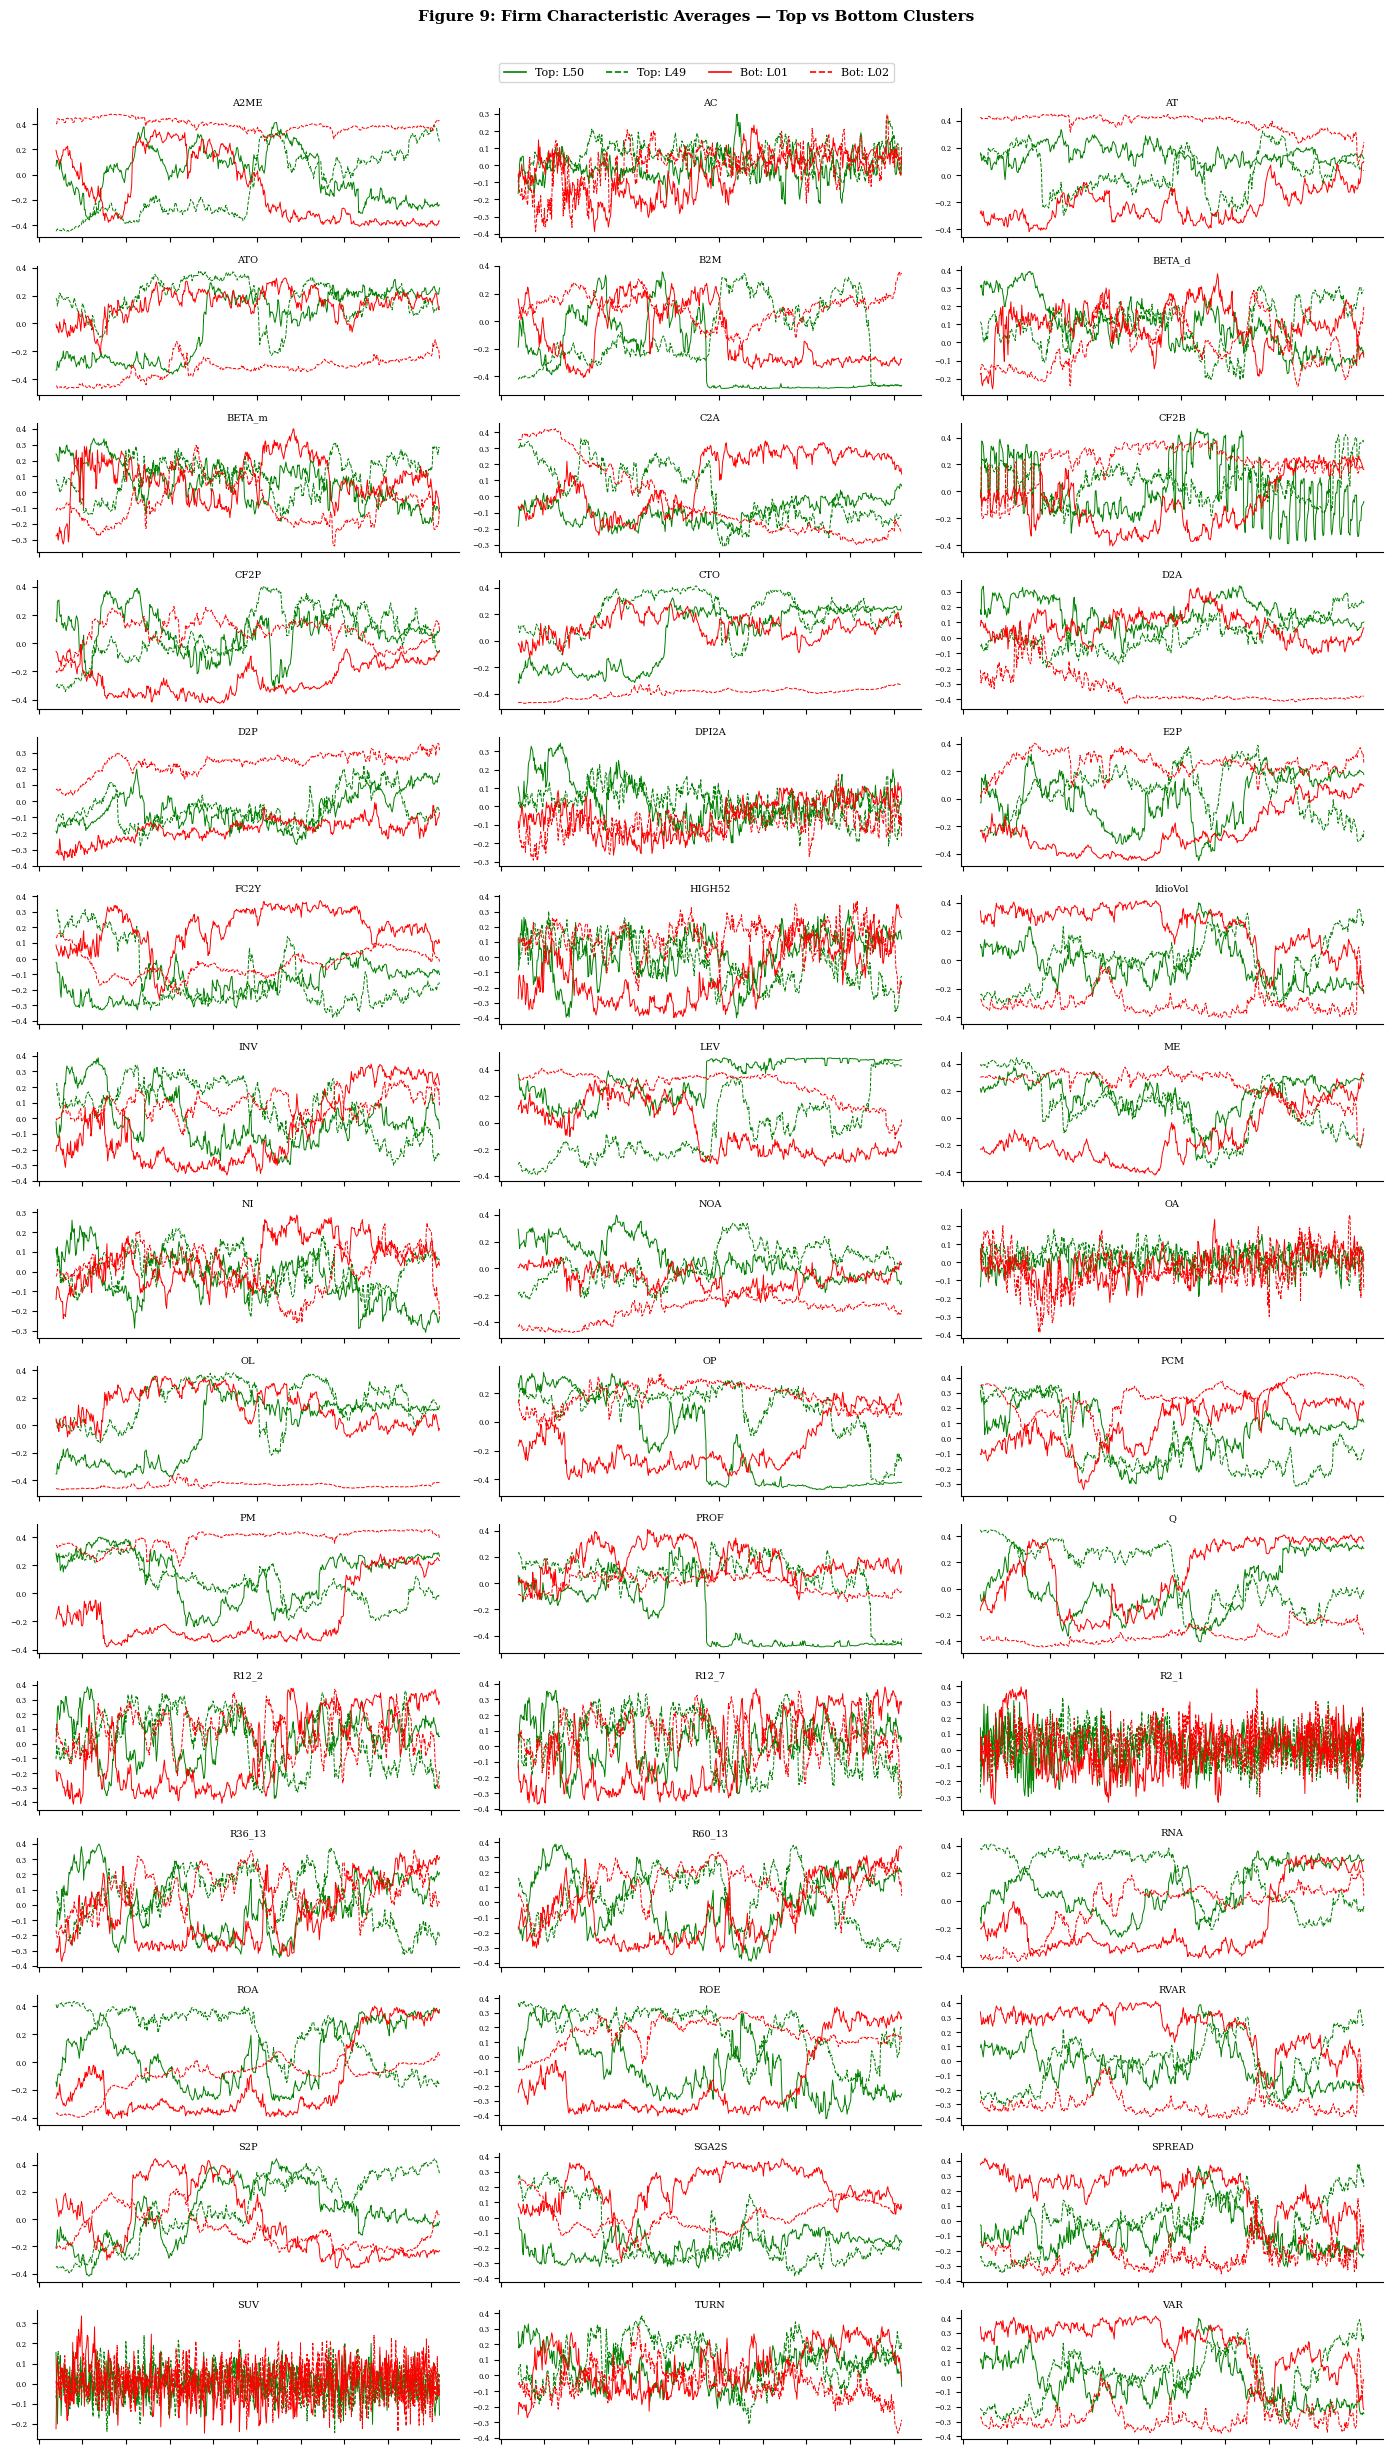

  Saved → output/figures/Figure10_Char_Profiles_BarChart.{pdf,png}


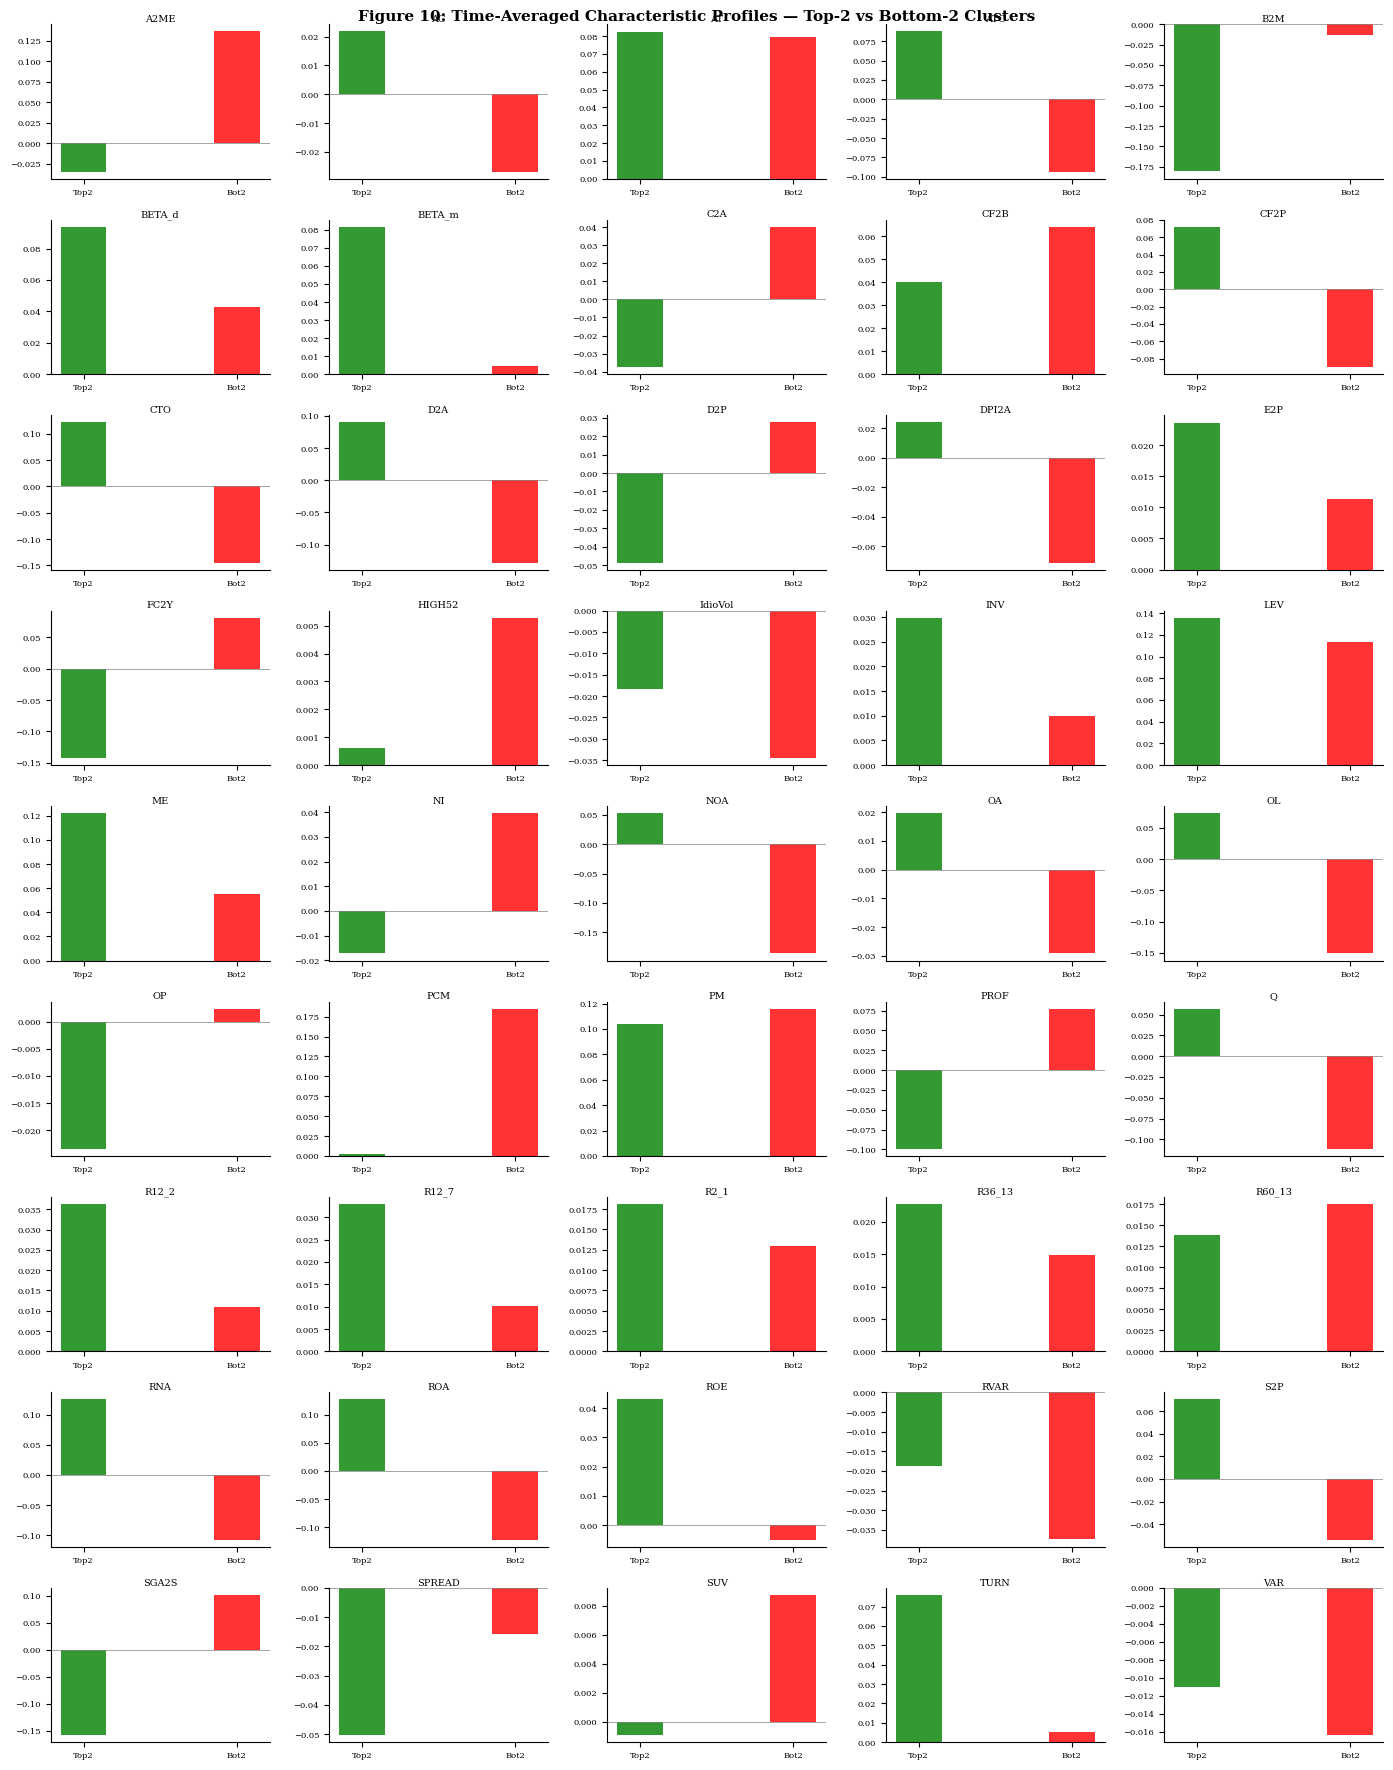

Figures 9 and 10 saved.


In [9]:
# ══ FIGURES 9 & 10: Characteristic profiles ════════════════════
if cent is not None:
    # Identify top-2 and bottom-2 clusters by mean return
    mean_r = cr_ranked.mean()
    top2   = list(mean_r.nlargest(2).index)
    bot2   = list(mean_r.nsmallest(2).index)
    
    # Figure 9: Time-series of centroid chars (master plot grid)
    n_chars = len(char_cols)
    ncols   = 3
    nrows   = int(np.ceil(n_chars / ncols))
    fig9, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 1.6), 
                               sharex=False, sharey=False)
    axes = axes.flatten()
    
    for i, char in enumerate(char_cols):
        ax = axes[i]
        for label, color, ls in [(top2[0],"green","-"),(top2[1],"green","--"),
                                  (bot2[0],"red",  "-"),(bot2[1],"red",  "--")]:
            orig_id = rev_map[label]
            sub = cent[cent["cluster_ranked"]==label][["year_month",char]].dropna()
            sub["date"] = pd.to_datetime(sub["year_month"])
            ax.plot(sub["date"], sub[char], color=color, linestyle=ls, linewidth=0.7)
        ax.set_title(char, fontsize=7, pad=2)
        ax.tick_params(labelsize=5)
        ax.set_xticklabels([])
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0],color="green",ls="-",lw=1.2,label=f"Top: {top2[0]}"),
        Line2D([0],[0],color="green",ls="--",lw=1.2,label=f"Top: {top2[1]}"),
        Line2D([0],[0],color="red",  ls="-",lw=1.2,label=f"Bot: {bot2[0]}"),
        Line2D([0],[0],color="red",  ls="--",lw=1.2,label=f"Bot: {bot2[1]}"),
    ]
    fig9.legend(handles=legend_elements, loc="upper center", ncol=4,
                fontsize=8, bbox_to_anchor=(0.5, 1.0))
    fig9.suptitle("Figure 9: Firm Characteristic Averages — Top vs Bottom Clusters",
                  fontsize=11, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_figure(fig9, "Figure9_Char_Profiles_TimeSeries")
    plt.show()
    
    # Figure 10: Bar chart (time-averaged)
    top_avg = cent[cent["cluster_ranked"].isin(top2)].groupby("cluster_ranked")[char_cols].mean()
    bot_avg = cent[cent["cluster_ranked"].isin(bot2)].groupby("cluster_ranked")[char_cols].mean()
    
    top_mean = top_avg.mean()
    bot_mean = bot_avg.mean()
    
    fig10, axes10 = plt.subplots(9, 5, figsize=(14, 18))
    axes10 = axes10.flatten()
    for i, char in enumerate(char_cols[:45]):
        ax = axes10[i]
        ax.bar(["Top2"], [top_mean[char]], color="green", alpha=0.8, width=0.3)
        ax.bar(["Bot2"], [bot_mean[char]], color="red",   alpha=0.8, width=0.3)
        ax.set_title(char, fontsize=7, pad=2)
        ax.tick_params(labelsize=6)
        ax.axhline(0, color="grey", linewidth=0.5)
    for j in range(len(char_cols), len(axes10)): axes10[j].set_visible(False)
    fig10.suptitle("Figure 10: Time-Averaged Characteristic Profiles — Top-2 vs Bottom-2 Clusters",
                   fontsize=11, fontweight="bold")
    plt.tight_layout()
    save_figure(fig10, "Figure10_Char_Profiles_BarChart")
    plt.show()
    print("Figures 9 and 10 saved.")